In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('Housing.csv')

In [3]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [5]:
data.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [6]:
data.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [7]:
data.select_dtypes(include=('int64','float64')).columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object')

In [17]:
X = data.drop(['mainroad', 'guestroom','basement','hotwaterheating','airconditioning','prefarea','price','furnishingstatus'], axis=1)
y = data['price']

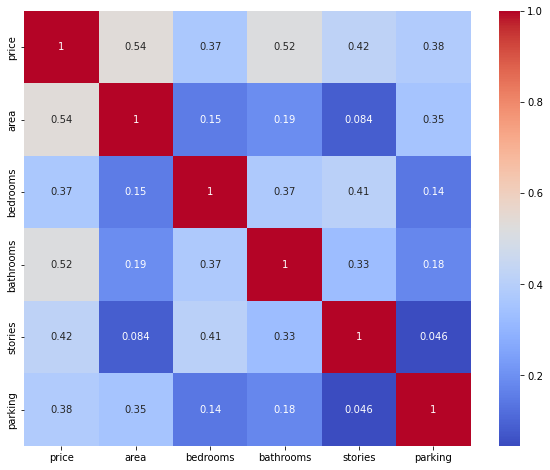

In [18]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.show()

The heatmap shows that Area (0.54) and Bathrooms (0.52) have the strongest positive relationship with house price. This indicates that larger houses and houses with more bathrooms tend to have higher prices. Bedrooms, Stories, and Parking also contribute positively to price, but their impact is comparatively moderate. Overall, house price depends on multiple features rather than a single factor.

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3 , random_state=42)

In [20]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [21]:
lr.fit(X_train, y_train)

LinearRegression()

In [22]:
lr.coef_

array([3.29285878e+02, 1.61077479e+05, 1.19412059e+06, 4.72530548e+05,
       3.95480372e+05])

In [23]:
lr.intercept_

-17122.995142479427

In [24]:
y_pred_train =lr.predict(X_train)

In [25]:
from sklearn.metrics import (mean_absolute_error , mean_squared_error ,r2_score)

In [26]:
mae = mean_absolute_error(y_train,y_pred_train)
mse = mean_squared_error (y_train,y_pred_train)
rmse = mse ** 0.5
r2 = r2_score(y_train,y_pred_train)

print("MAE:" , mae)
print ("MSE:" ,mse)
print("RMSE:" , rmse)
print("R2 Score:",r2)

MAE: 851921.2094211405
MSE: 1320370733904.5688
RMSE: 1149073.8592033884
R2 Score: 0.5797092579395215


In [27]:
y_pred_test =lr.predict(X_test)

In [28]:
mae = mean_absolute_error(y_test,y_pred_test)
mse = mean_squared_error (y_test,y_pred_test)
rmse = mse ** 0.5
r2 = r2_score(y_test,y_pred_test)

print("MAE:" , mae)
print ("MSE:" ,mse)
print("RMSE:" , rmse)
print("R2 Score:",r2)

MAE: 1065137.8263727794
MSE: 2044165115591.7861
RMSE: 1429743.0243200301
R2 Score: 0.5253182966980272


In [29]:
result = pd.DataFrame({
    "Actual": y_test,
    "Preidicted":y_pred_test})
result.head()

,Actual,Preidicted
316,4060000,6.298756e+06
77,6650000,6.412300e+06
360,3710000,3.301998e+06
90,6440000,4.251721e+06
493,2800000,3.436733e+06


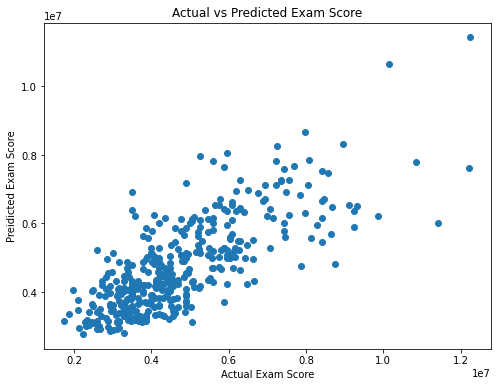

In [30]:
plt.figure(figsize=(8,6))
plt.scatter(y_train,y_pred_train)
plt.xlabel("Actual Exam Score")
plt.ylabel("Preidicted Exam Score")
plt.title("Actual vs Predicted Exam Score")
plt.show()

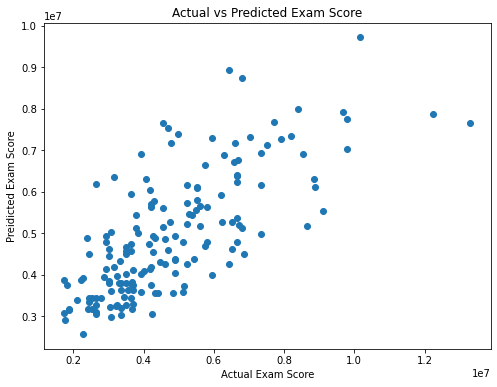

In [31]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred_test)
plt.xlabel("Actual Exam Score")
plt.ylabel("Preidicted Exam Score")
plt.title("Actual vs Predicted Exam Score")
plt.show()

In [34]:
area = float(input("Enter area: "))
bedrooms = float(input("Enter bedrooms: "))
bathrooms = float(input("Enter bathrooms: "))
stories = float(input("Enter stories: "))
parking = float(input("Enter parking area: "))

Housing = pd.DataFrame({
    'area': [area],
    'bedrooms': [bedrooms],
    'bathrooms': [bathrooms],
    'stories': [stories],
    'parking': [parking],
    
})

predicted_score = lr.predict(Housing)

print("Predicted House Pice:", predicted_score[0])

Enter area:  7420
Enter bedrooms:  4
Enter bathrooms:  2
Enter stories:  3
Enter parking area:  2


Predicted House Pice: 7667281.701863256


In [35]:
import joblib
joblib.dump(lr,'housig_price_predictor.joblib')

['housig_price_predictor.joblib']